# Analysis of Stock Returns

*Investors often look at the relationship between the returns of different stocks to make informed decisions. Covariance and correlation are two statistical measures that help in understanding this relationship. Covariance indicates the direction of the linear relationship between the returns of two stocks, while correlation indicates both the strength and direction of this relationship.*

You are given the monthly returns of two stocks, Stock A and Stock B, over a period of one year. The returns (in percentage) for each month are as follows:

Stock A: [2.5, 3.0, -2.0, 4.0, 3.5, -1.5, 2.0, -0.5, 1.5, 2.5, -1.0, 3.0]

Stock B: [1.5, 2.0, -1.0, 3.0, 2.5, -2.0, 1.0, -0.5, 1.0, 2.0, -0.5, 2.5]


**Tasks:**

1. Calculate the mean returns for Stock A and Stock B.
2. Compute the covariance between the returns of Stock A and Stock B.
3. Compute the correlation coefficient between the returns of Stock A and Stock B.
4. Interpret the results of the covariance and correlation

In [8]:
import numpy as np
import math
import random
from scipy.stats  import pearsonr


In [9]:
!nvidia-smi

Sat Jun 13 17:11:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
# Step 1: Define the returns of Stock A and Stock B
stock_A_returns = np.array([2.5, 3.0, -2.0, 4.0, 3.5, -1.5, 2.0, -0.5, 1.5, 2.5, -1.0, 3.0])
stock_B_returns = np.array([1.5, 2.0, -1.0, 3.0, 2.5, -2.0, 1.0, -0.5, 1.0, 2.0, -0.5, 2.5])

In [11]:
# Step 2: Calculate the mean returns for Stock A and Stock B
stock_A_mean=stock_A_returns.mean()
stock_B_mean=stock_B_returns.mean()

print("Mean of Stock A is:",stock_A_mean )
print("Mean of Stock A is:",stock_B_mean )

Mean of Stock A is: 1.4166666666666667
Mean of Stock A is: 0.9583333333333334


In [12]:
# Step 3: Compute the covariance between the returns of Stock A and Stock B
covar_n=0
covar=0
for i in range(len(stock_A_returns)):
  covar_n += (stock_A_returns[i]-stock_A_mean) * (stock_B_returns[i]-stock_B_mean)
covar=covar_n/(len(stock_A_returns)-1)

print(f'covariance between the returns of Stock A and Stock B is :{covar}')
covar_n_1= sum((stock_A_returns-stock_A_mean)*(stock_B_returns-stock_B_mean))
print(f'covariance between the returns of Stock A and Stock B is :{covar_n_1/(len(stock_A_returns)-1)}')



covariance between the returns of Stock A and Stock B is :3.2689393939393936
covariance between the returns of Stock A and Stock B is :3.2689393939393936


In [13]:
# Step 4: Compute the correlation coefficient between the returns of Stock A and Stock B


std_A= math.sqrt((sum((stock_A_returns-stock_A_mean)**2))/(len(stock_A_returns)-1))
std_B=math.sqrt((sum((stock_B_returns-stock_B_mean)**2))/(len(stock_B_returns)-1))

#print(f'variance of Stock A is :{var_A} and Stock B is: {var_B}')
print(f'Std Dev of Stock A is :{std_A} and std dev of Stock B is: {std_B}')
print(f'correlation coefficient between the returns of Stock A and Stock B is :{covar/(std_A*std_B)}')

# calculate Pearson's correlation
corr, _ = pearsonr(stock_A_returns, stock_B_returns)
print('Pearsons correlation: %.3f' % corr)

Std Dev of Stock A is :2.097978825325735 and std dev of Stock B is: 1.6019637570144583
correlation coefficient between the returns of Stock A and Stock B is :0.9726421407657766
Pearsons correlation: 0.973


In [14]:
# Interpretation of results
#A pearson corelation of 0.97 indicates they are positively corelated and are highly co-related

# Analysis of Heights

*John is visiting planet Utopia and he figures out that the population is 1 million. Utopians are very tall and their height varies between 180 cm and 250 cm. John tries to estimate the population size by randomly identifying 10000 people n times and finds their mean heights. Can you help John do the following using python?*

1. Generate population samples of size 10000 with height between 180 cm and 250 cm by varying n(number of times you identify 10000 random people) as following:

a. 5

b. 10

c. 100

d. 1000

e. 10000

In [15]:
lower_bound=180
upper_bound=250
population_size=1000000
sample_size=10000

utopia_population = np.random.uniform(lower_bound,upper_bound,population_size)
population_mean=utopia_population.mean()
print("Population Mean:",population_mean)

#due to time consumption only limiting to max of 10000 . we can use 100000 in vecorization version in next version below
#n=[5,10,100,1000,10000]
n=[5,10,100,1000]
for ele in n:
    sample_means=[]
    for i in range(ele):
      random_indices=np.random.choice(population_size,sample_size,replace=False)
      current_population=utopia_population[random_indices]
      sample_means.append(current_population.mean())
    print("Error in Means population mean - sample mean",population_mean-np.mean(sample_means))

Population Mean: 214.97920708321695
Error in Means population mean - sample mean -0.049247766033744256
Error in Means population mean - sample mean 0.10778018260040767
Error in Means population mean - sample mean -0.007226662218698721
Error in Means population mean - sample mean 0.0060213103306807625


In [16]:
#faster verctorization version:
lower_bound=180
upper_bound=250
population_size=1000000
sample_size=10000

utopia_population = np.random.uniform(lower_bound,upper_bound,population_size)
population_mean=utopia_population.mean()
print("Population Mean:",population_mean)

#due to time consumption optimized vecorization version
n=[5,10,100,1000,10000]

for ele in n:
  # OPTIMIZATION: Instead of an inner loop, draw a massive grid of random indices all at once!
    # This creates a 2D grid with 'ele' rows and 'sample_size' columns
      random_indices=np.random.randint(0,population_size,size=(ele,sample_size))

      # Map the grid directly to population heights
      current_population=utopia_population[random_indices]

      # Calculate the mean across the horizontal rows, then average those results
      all_sample_means = current_population.mean(axis=1)
      final_experiment_mean = all_sample_means.mean()
      print("Error in Means population mean - sample mean",population_mean-final_experiment_mean)


Population Mean: 215.02302651528413
Error in Means population mean - sample mean -0.018578820436630394
Error in Means population mean - sample mean -0.07556158631655308
Error in Means population mean - sample mean 0.05343847918865663
Error in Means population mean - sample mean 0.0077649992587396355
Error in Means population mean - sample mean 0.0004550010629031931


In [17]:
random_indices[5]

array([118021, 783441, 189770, ..., 682609, 540228,  66291])

2. Plot histogram of the population means

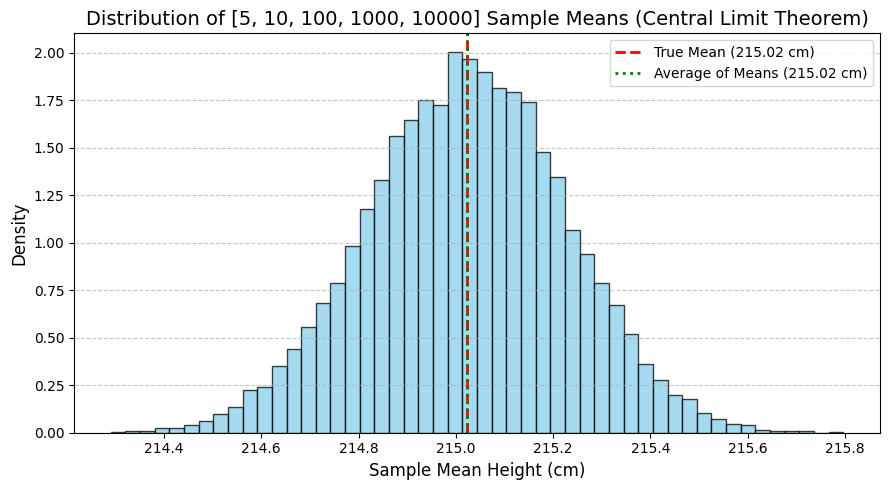

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.hist(all_sample_means,bins=50,color='skyblue', edgecolor='black', alpha=0.75, density=True)
# 4. Add markers for the true mean vs John's averages
plt.axvline(population_mean, color='red', linestyle='dashed', linewidth=2, label=f'True Mean ({population_mean:.2f} cm)')
plt.axvline(final_experiment_mean, color='green', linestyle='dotted', linewidth=2,label=f'Average of Means ({all_sample_means.mean():.2f} cm)')

# 5. Format labels and titles
plt.title(f'Distribution of {n} Sample Means (Central Limit Theorem)', fontsize=14)
plt.xlabel('Sample Mean Height (cm)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Render plot on your machine
plt.tight_layout()

3. Does the population mean approach normal distribution as the sample size increases?